In [44]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [45]:
def get_column(data, index):

    result = np.array(data)[:, index]

    return result

In [46]:
def prepare_data(file_name_dataset):
    data = np.genfromtxt(file_name_dataset, delimiter=',', skip_header=1).tolist()
    N = len(data)

    tv_data = get_column(data, 0)

    radio_data = get_column(data, 1)

    newspaper_data = get_column(data, 2)

    sales_data = get_column(data, 3)

    X = [tv_data, radio_data, newspaper_data]
    y = sales_data
    
    return X,y

In [47]:
def intialize_params():
    w1, w2, w3, b = (0.016992259082509283, 0.0070783670518262355, -0.002307860847821344, 0)
    #Replaced with random initlization in real-world application
    return w1, w2, w3, b

In [48]:
def predict(x1, x2, x3, w1, w2, w3, b):

    result = x1*w1 + x2*w2 + x3*w3 + b

    return result

In [49]:
y = predict(x1=1, x2=1, x3=1, w1=0, w2=0.5, w3=0, b=0.5)
print(y)

1.0


In [50]:
def compute_loss(y_hat, y):

    result = (y_hat - y)**2

    return result

In [51]:
l = compute_loss(y_hat=1, y=0.5)
print(l)

0.25


In [52]:
def compute_gradient_wi(xi, y, y_hat):
    dl_dwi = 2*xi*((y_hat - y))

    return dl_dwi

def compute_gradient_b(y, y_hat):
    dl_db = 2*(y_hat - y)

    return dl_db

In [53]:
g_wi = compute_gradient_wi(xi=1.0, y=1.0, y_hat=0.5)
print(g_wi)

g_b = compute_gradient_b(y=2.0, y_hat=0.5)
print(g_b)

-1.0
-3.0


In [54]:
def update_weight_wi(wi, dl_dwi, lr):

    wi = wi - dl_dwi*lr

    return wi

def update_weight_b(b, dl_db, lr):

    b = b - dl_db*lr

    return b

In [55]:
after_wi = update_weight_wi(wi=1.0, dl_dwi=-0.5, lr=1e-5)
print(after_wi)

after_b = update_weight_b(b=0.5, dl_db=-1.0, lr=1e-5)
print(after_b)

1.000005
0.50001


In [56]:
def implement_linear_regression(X_data, y_data, epoch_max = 50,lr = 1e-5):
    losses = []

    w1, w2, w3, b = intialize_params()
    N = len(y_data)
    for epoch in range(epoch_max):
        for i in range(N):
            x1 = X_data[0][i]
            x2 = X_data[1][i]
            x3 = X_data[2][i]

            y = y_data[i]

            #output
            y_hat = predict(x1, x2, x3, w1, w2, w3, b)

            #loss calc
            loss = compute_loss(y, y_hat)

            #gradient
            dl_dw1 = compute_gradient_wi(x1, y, y_hat)
            dl_dw2 = compute_gradient_wi(x2, y, y_hat)
            dl_dw3 = compute_gradient_wi(x3, y, y_hat)
            dl_db = compute_gradient_b(y, y_hat)

            #update
            w1 = update_weight_wi(w1, dl_dw1, lr)
            w2 = update_weight_wi(w2, dl_dw2, lr)
            w3 = update_weight_wi(w3, dl_dw3, lr)
            b = update_weight_b(b, dl_db, lr)

            losses.append(loss)

    return (w1,w2,w3,b, losses)

In [57]:
X, y = prepare_data('data/advertising.csv')
list = [sum(X[0][:5]), sum(X[1][:5]), sum(X[2][:5]), sum(y[:5])]
print(list)

[np.float64(624.1), np.float64(175.10000000000002), np.float64(300.5), np.float64(78.9)]


[np.float64(326.9667843262905), np.float64(16.813661135067065), np.float64(53.03153479688057), np.float64(9.097721194637154), np.float64(3.6424308051668244), np.float64(7.563752860234681), np.float64(22.66109565599889), np.float64(0.2903595791172754), np.float64(14.838547485180843), np.float64(24.076309414072263), np.float64(40.37629497003938), np.float64(5.1268803606027795), np.float64(13.518222414308081), np.float64(29.260234447005313), np.float64(6.298237914505083), np.float64(9.162549922566846), np.float64(0.026579461634628335), np.float64(26.706667137444764), np.float64(31.588025437397253), np.float64(7.299166664675038), np.float64(4.87832661040257), np.float64(0.06589490698448672), np.float64(4.659432930180689), np.float64(8.197887498801554), np.float64(10.726801676543044), np.float64(46.88850553057548), np.float64(37.00183951157569), np.float64(7.945648850356329), np.float64(13.192456099944478), np.float64(12.99508446043089), np.float64(3.692858118961234), np.float64(8.943627477

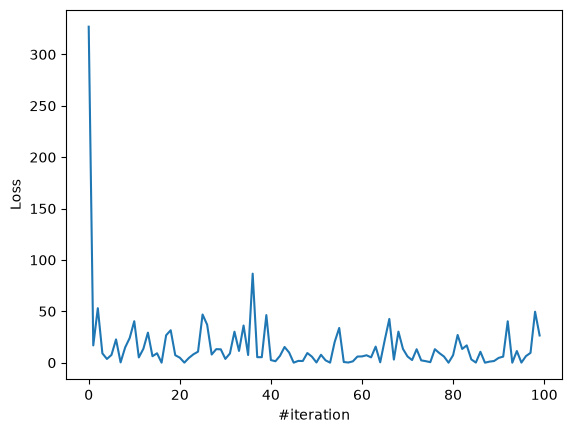

0.07405984066396477 0.15917360263437663 0.017561197559948935


In [59]:
(w1,w2,w3,b, losses) = implement_linear_regression(X,y)
print(losses[0:100])
plt.plot(losses[0:100])
plt.xlabel("#iteration")
plt.ylabel("Loss")
plt.show()
print(w1, w2, w3)

In [60]:
tv = 19.2
radio = 35.9
newspaper = 51.3

X, y = prepare_data('data/advertising.csv')
(w1, w2, w3, b, losses) = implement_linear_regression(X, y, epoch_max=50, lr=1e-5)

sales = predict(tv, radio, newspaper, w1, w2, w3, b)
print(f"predicted sales is {sales}")

predicted sales is 8.176413319549823
